In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import enrichmap as em
import pickle

from scipy import stats
from scipy.stats import spearmanr, linregress, mannwhitneyu
from scipy.sparse import issparse

In [4]:
sc.set_figure_params(frameon=False, fontsize=8)
sc.settings._vector_friendly = False

In [5]:
# repository root (the folder containing `notebooks/`); safe to re-run this cell
project_dir = os.getcwd()
if os.path.basename(project_dir) == "notebooks":
    project_dir = os.path.dirname(project_dir)
project_dir += "/"
working_dir = project_dir
os.chdir(working_dir)

figure_dir = working_dir + "figures/"
os.makedirs(figure_dir, exist_ok=True)
processed_data = working_dir + "processed_data/"
os.makedirs(processed_data, exist_ok=True)

spot_size = 1.5

In [6]:
adata = sq.datasets.visium_hne_adata()
adata.X = adata.raw.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [7]:
cell_type_1 = "Pyramidal_layer"
cell_type_2 = "Striatum"

with open(f"{cell_type_1}_signatures.pkl", "rb") as f:
    signature_dict_pyramidal = pickle.load(f)

with open(f"{cell_type_2}_signatures.pkl", "rb") as f:
    signature_dict_striatum = pickle.load(f)

signature_1 = signature_dict_pyramidal[f"{cell_type_1}_top10"]
signature_2 = signature_dict_striatum[f"{cell_type_2}_top10"]

print(f"{cell_type_1} ({len(signature_1)} genes): {list(signature_1)}")
print(f"{cell_type_2} ({len(signature_2)} genes): {list(signature_2)}")
print(f"\nGround-truth clusters: {sorted(adata.obs['cluster'].unique())}")
print(f"  {cell_type_1}: {(adata.obs['cluster'] == cell_type_1).sum()} spots")
print(f"  {cell_type_2}: {(adata.obs['cluster'] == cell_type_2).sum()} spots")

Pyramidal_layer (10 genes): ['Lefty1', '6330420H09Rik', 'B230110G15Rik', 'Fgf16', 'Fibcd1', '4921539H07Rik', 'Spink8', 'Efcab6', 'Tmprss6', 'Gm2115']
Striatum (10 genes): ['Ucn3', 'Cyp19a1', 'Adora2a', 'Ccdc42', 'Ido1', 'Sstr5', 'Chrna10', 'Gm48485', '6430628N08Rik', 'Penk']

Ground-truth clusters: ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', 'Cortex_5', 'Fiber_tract', 'Hippocampus', 'Hypothalamus_1', 'Hypothalamus_2', 'Lateral_ventricle', 'Pyramidal_layer', 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']
  Pyramidal_layer: 42 spots
  Striatum: 153 spots


In [8]:
# Compute per-gene mean and CV across all spots
if issparse(adata.X):
    gene_means_arr = np.asarray(adata.X.mean(axis=0)).flatten()
    gene_sq_means  = np.asarray(adata.X.multiply(adata.X).mean(axis=0)).flatten()
    gene_vars_arr  = gene_sq_means - gene_means_arr ** 2
else:
    gene_means_arr = adata.X.mean(axis=0)
    gene_vars_arr  = adata.X.var(axis=0)

gene_mean_series = pd.Series(gene_means_arr, index=adata.var_names)
gene_cv_series   = pd.Series(
    np.where(gene_means_arr > 0,
             np.sqrt(np.maximum(gene_vars_arr, 0)) / gene_means_arr, 0.0),
    index=adata.var_names,
)

all_sig_genes = set(list(signature_1) + list(signature_2))

# --- Noise gene selection principle ---
# CV is exactly the criterion EnrichMap uses to assign weights.
# Noise genes must have CV strictly below the MINIMUM CV of any signal gene,
# guaranteeing that CV inference ranks every signal gene above every noise gene.
# An expression floor (Q25 of expressed background) ensures noise genes actually
# contribute to the raw score, making the raw vs inferred comparison meaningful.

sig_cvs      = gene_cv_series[[g for g in all_sig_genes if g in adata.var_names]]
min_sig_cv   = sig_cvs.min()

bg_expressed = [g for g in adata.var_names
                if g not in all_sig_genes and gene_mean_series[g] > 0]
expr_floor   = gene_mean_series[bg_expressed].quantile(0.25)

noise_candidates = [
    g for g in bg_expressed
    if gene_cv_series[g] < min_sig_cv
    and gene_mean_series[g] >= expr_floor
]

print(f"Signal CVs — min: {min_sig_cv:.3f}, max: {sig_cvs.max():.3f}")
print(f"Expression floor (Q25 of expressed background): {expr_floor:.4f}")
print(f"{len(noise_candidates)} candidates with CV < min(signal CV) and mean ≥ floor")

rng_noise   = np.random.default_rng(seed=42)
noise_genes = sorted(rng_noise.choice(noise_candidates, size=10, replace=False).tolist())

selected_stats = pd.DataFrame({
    "mean": gene_mean_series[noise_genes],
    "CV":   gene_cv_series[noise_genes],
})
print(f"\nSelected noise genes:\n{selected_stats.round(4).to_string()}")

Signal CVs — min: 1.529, max: 13.912
Expression floor (Q25 of expressed background): 0.0091
6899 candidates with CV < min(signal CV) and mean ≥ floor

Selected noise genes:
           mean      CV
Anp32e   0.3428  0.8508
Apba2    0.5248  0.6997
Clptm1l  0.5808  0.5824
Kcnh3    0.3551  1.0707
Mdk      0.2720  1.1235
Prkra    0.1382  1.4897
Rbm6     0.1789  1.2632
Sh3gl3   0.3849  0.9603
Ssb      0.5575  0.5996
Trappc1  0.4057  0.7625


## Experimental Design

All three conditions receive the **same combined gene set** (`signal_genes + noise_genes`) and call the **same `em.tl.score()` function**. Only the weights differ:

| # | Condition | Gene set | Weights | Via |
|---|-----------|----------|---------|-----|
| A | **Known weights** | signal + noise | signal ∈ (0, 1], noise = 0 | `gene_weights=` |
| B | **Inferred weights** | signal + noise | CV-inferred | `gene_set=` |
| C | **Raw score** | signal + noise | Uniform = 1 | `gene_weights=` |

A single shared `noise_genes` set (10 genes) is used for **both** cell types, selected by two criteria:

1. **CV < minimum CV of any signal gene** — since CV is exactly the criterion EnrichMap uses to assign weights, this single rule guarantees that CV inference always assigns a higher weight to every signal gene than to every noise gene. No noise gene can compete with any signal gene in the inferred condition.
2. **Mean expression ≥ Q25 of expressed background genes** — ensures noise genes actually contribute to the raw score, making the raw vs inferred comparison informative. Without an expression floor, flat noise adds a constant offset to all spots and the dilution effect vanishes.

Isolating the weight as the sole variable enables three comparisons:
- **A vs C**: does silencing noise genes (known weights) outperform treating all genes equally?
- **B vs C**: does CV-inferred weighting recover a signal that equal weighting cannot?
- **A vs B**: how close is unsupervised CV inference to provided weights?

## Scoring

In [9]:
rng = np.random.default_rng(seed=0)

def assign_weights(pos_genes, zero_genes, rng):
    """Random uniform weights in (0, 1] for pos_genes; weight=0 for zero_genes."""
    weights = {}
    pos_w = rng.uniform(0, 1, size=len(pos_genes))
    for gene, w in zip(pos_genes, pos_w):
        weights[gene] = round(float(w), 4)
    for gene in zero_genes:
        weights[gene] = 0
    return weights

### Condition A — Known Weights

Signal genes receive random uniform weights ∈ (0, 1]; noise genes are set to 0. Because `em.tl.score` normalises by the sum of absolute weights, zero-weighted genes contribute nothing — the score is a weighted mean of signal genes only.

In [10]:
known_weights_dict = {
    f"{cell_type_1}_known": assign_weights(
        pos_genes=list(signature_1), zero_genes=noise_genes, rng=rng
    ),
    f"{cell_type_2}_known": assign_weights(
        pos_genes=list(signature_2), zero_genes=noise_genes, rng=rng
    ),
}

print(f"Known weights for {cell_type_1}:")
for gene, w in known_weights_dict[f"{cell_type_1}_known"].items():
    print(f"  {gene}: {w}")

em.tl.score(adata, gene_weights=known_weights_dict)

Known weights for Pyramidal_layer:
  Lefty1: 0.637
  6330420H09Rik: 0.2698
  B230110G15Rik: 0.041
  Fgf16: 0.0165
  Fibcd1: 0.8133
  4921539H07Rik: 0.9128
  Spink8: 0.6066
  Efcab6: 0.7295
  Tmprss6: 0.5436
  Gm2115: 0.9351
  Anp32e: 0
  Apba2: 0
  Clptm1l: 0
  Kcnh3: 0
  Mdk: 0
  Prkra: 0
  Rbm6: 0
  Sh3gl3: 0
  Ssb: 0
  Trappc1: 0


Scoring Pyramidal_layer_known: 20/20 genes found:   0%|          | 0/2 [00:00<?, ?it/s]

Scoring Striatum_known: 20/20 genes found: 100%|██████████| 2/2 [00:13<00:00,  6.79s/it]       


### Condition B — Inferred Weights

Same combined gene set (signal + noise), no weights provided. EnrichMap infers weights via coefficient of variation (CV) over all spots. The question is whether CV inference can identify that signal genes are more relevant — without any prior knowledge — and recover a score close to the known-weights baseline.

In [11]:
inferred_dict = {
    f"{cell_type_1}_inferred": list(signature_1) + noise_genes,
    f"{cell_type_2}_inferred": list(signature_2) + noise_genes,
}

em.tl.score(adata, gene_set=inferred_dict)

  0%|          | 0/2 [00:00<?, ?it/s]

Scoring Striatum_inferred: 20/20 genes found: 100%|██████████| 2/2 [00:13<00:00,  6.87s/it]       


### Condition C — Raw Score (Uniform Weights)

Same combined gene set and same `em.tl.score()` call, but with every gene assigned weight = 1. All genes — both signal and noise — contribute equally to the final score. The noise genes dilute the signal, representing the worst-case equal-weighting baseline.

In [12]:
raw_weights_dict = {
    f"{cell_type_1}_raw": {gene: 1 for gene in list(signature_1) + noise_genes},
    f"{cell_type_2}_raw": {gene: 1 for gene in list(signature_2) + noise_genes},
}

em.tl.score(adata, gene_weights=raw_weights_dict)

Scoring Striatum_raw: 20/20 genes found: 100%|██████████| 2/2 [00:12<00:00,  6.46s/it]       


## Score Column Registry

In [13]:
CONDITIONS = [
    {"key": "known",    "label": "Known weights",    "col_suffix": "known_score"},
    {"key": "inferred", "label": "Inferred weights",  "col_suffix": "inferred_score"},
    {"key": "raw",      "label": "Raw score",         "col_suffix": "raw_score"},
]

CONDITION_COLORS = {
    "known":    "#6D4AFF",
    "inferred": "#A792FF",
    "raw":      "#8D8D8D",
}

registry_df = pd.DataFrame([
    {
        "cell_type": ct,
        "key":       cond["key"],
        "label":     cond["label"],
        "col":       f"{ct}_{cond['col_suffix']}",
        "color":     CONDITION_COLORS[cond["key"]],
    }
    for ct in [cell_type_1, cell_type_2]
    for cond in CONDITIONS
])

registry_df = registry_df[registry_df["col"].isin(adata.obs.columns)].reset_index(drop=True)
print(f"{len(registry_df)} score columns registered")
registry_df[["cell_type", "key", "label", "col"]]

6 score columns registered


,cell_type,key,label,col
0,Pyramidal_layer,known,Known weights,Pyramidal_layer_known_score
1,Pyramidal_layer,inferred,Inferred weights,Pyramidal_layer_inferred_score
2,Pyramidal_layer,raw,Raw score,Pyramidal_layer_raw_score
3,Striatum,known,Known weights,Striatum_known_score
4,Striatum,inferred,Inferred weights,Striatum_inferred_score
5,Striatum,raw,Raw score,Striatum_raw_score


## Spatial Maps

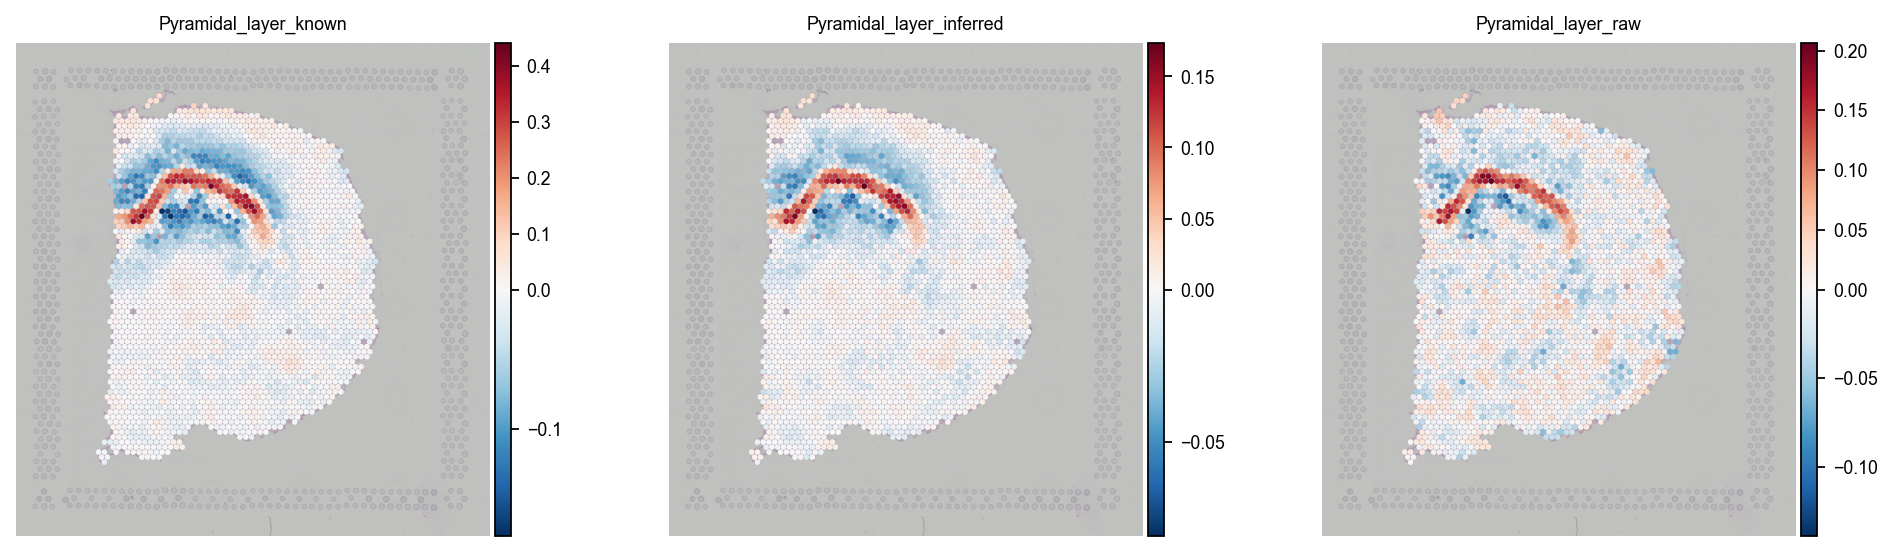

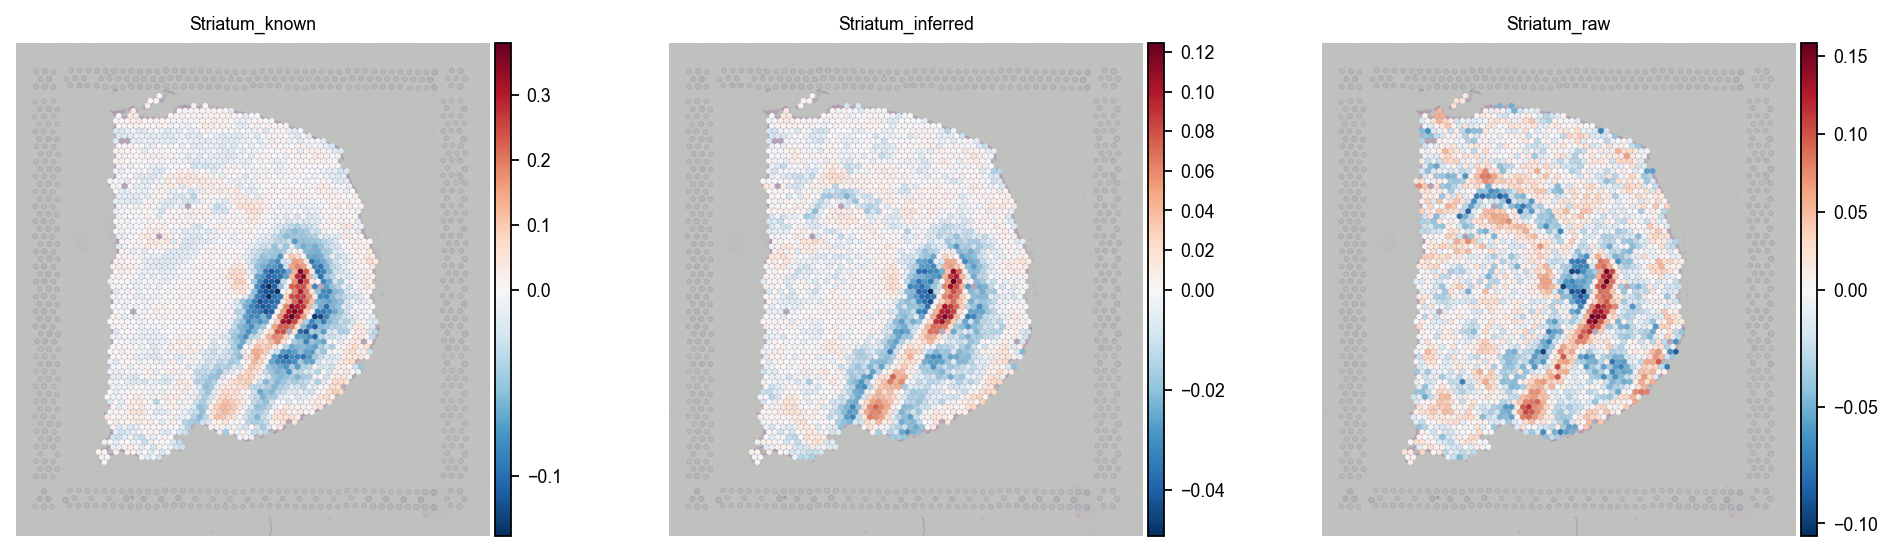

In [14]:
for ct in [cell_type_1, cell_type_2]:
    em.pl.spatial_enrichmap(
        adata,
        score_key=[f"{ct}_{c['col_suffix']}" for c in CONDITIONS],
        size=spot_size,
        ncols=3,
        cmap="RdBu_r",
        save=f"visium_spatial_enrichmap_weights_{ct}.pdf",
    )

## Score Distributions by Cluster

Spots grouped into the target cell type, the other named cell type, and all remaining clusters. A well-performing condition separates the target cluster from the rest.

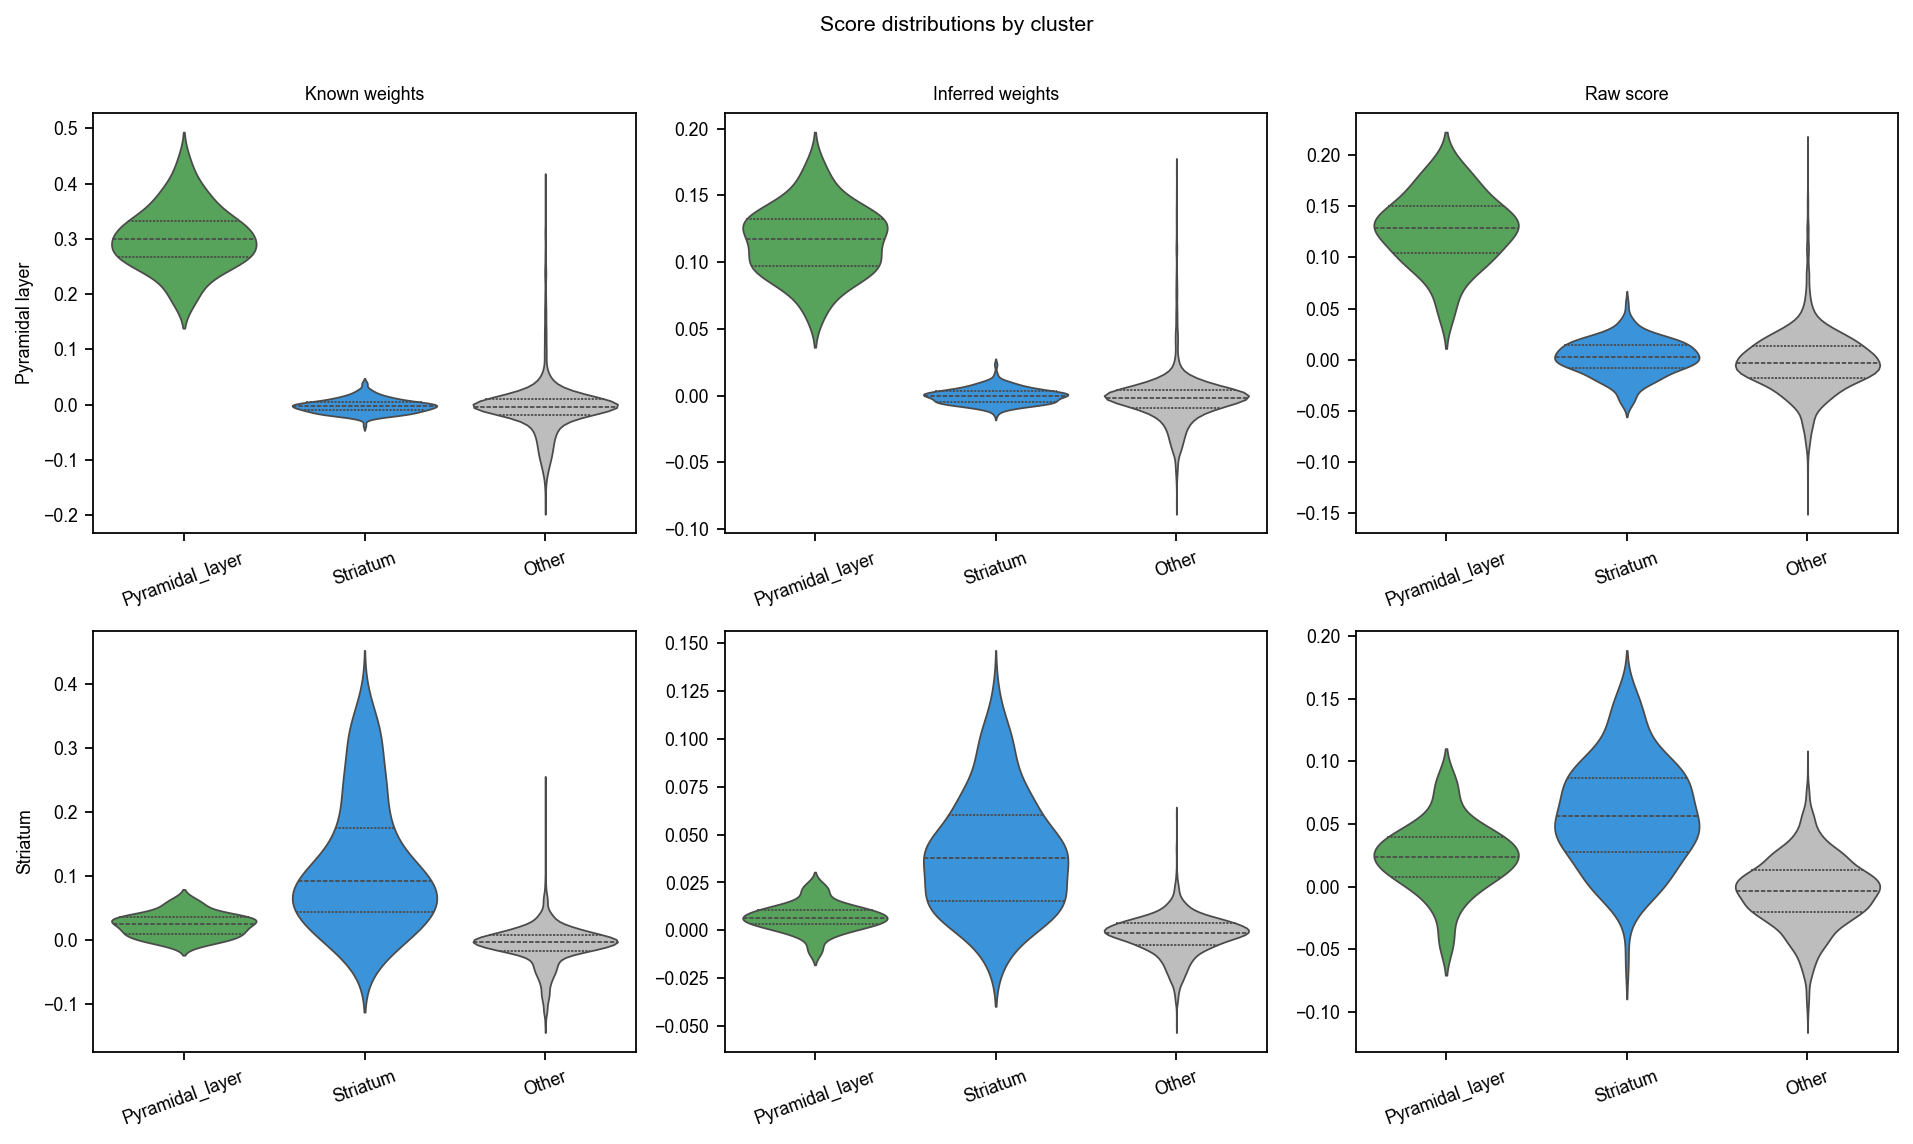

In [15]:
cluster_3 = adata.obs["cluster"].apply(
    lambda x: x if x in [cell_type_1, cell_type_2] else "Other"
)

CLUST_COLORS = {
    cell_type_1: "#4CAF50",
    cell_type_2: "#2196F3",
    "Other":     "#BDBDBD",
}
cluster_order = [cell_type_1, cell_type_2, "Other"]

fig, axes = plt.subplots(2, len(CONDITIONS), figsize=(4 * len(CONDITIONS), 7), sharey=False)

for row, ct in enumerate([cell_type_1, cell_type_2]):
    for col, cond in enumerate(CONDITIONS):
        ax = axes[row, col]
        df_plot = pd.DataFrame(
            {"score": adata.obs[f"{ct}_{cond['col_suffix']}"], "cluster": cluster_3}
        )
        sns.violinplot(
            data=df_plot, x="cluster", y="score",
            order=cluster_order, palette=CLUST_COLORS,
            inner="quart", ax=ax, linewidth=0.8,
        )
        ax.set_title(cond["label"] if row == 0 else "")
        ax.set_xlabel("")
        ax.set_ylabel(ct.replace("_", " ") if col == 0 else "")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(False)

plt.suptitle("Score distributions by cluster", y=1.01)
plt.tight_layout()
plt.savefig(f"{figure_dir}19_score_distributions.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

## Cohen's *d* — Score Separation

Pooled-std effect size between target-cluster spots and all others. Larger *d* = better separation.

Cohen's *d* is **not** bounded to [0, 1] — it can take any positive value. The conventional benchmarks (small ≥ 0.2, medium ≥ 0.5, large ≥ 0.8) are simply rule-of-thumb labels; values of 1, 3, or 6 are perfectly valid and indicate increasingly strong separation. In spatial transcriptomics, where cell-type markers can be highly cell-type-specific, *d* values well above 1 are expected.

In [16]:
def cohens_d(group1, group2):
    """Pooled-std Cohen's d (group1 is the positive class)."""
    n1, n2 = len(group1), len(group2)
    s_pooled = np.sqrt(
        ((n1 - 1) * np.var(group1, ddof=1) + (n2 - 1) * np.var(group2, ddof=1))
        / (n1 + n2 - 2)
    )
    return (np.mean(group1) - np.mean(group2)) / s_pooled if s_pooled > 0 else 0.0


cd_records = []
for _, row in registry_df.iterrows():
    ct  = row["cell_type"]
    col = row["col"]
    mask_target = (adata.obs["cluster"] == ct).values
    scores = adata.obs[col].values
    d = cohens_d(scores[mask_target], scores[~mask_target])
    cd_records.append({**row.to_dict(), "cohens_d": d})

cd_df = pd.DataFrame(cd_records)
print(cd_df[["cell_type", "label", "cohens_d"]].to_string(index=False))

      cell_type            label  cohens_d
Pyramidal_layer    Known weights  6.245838
Pyramidal_layer Inferred weights  6.215001
Pyramidal_layer        Raw score  4.554517
       Striatum    Known weights  3.268769
       Striatum Inferred weights  3.439257
       Striatum        Raw score  2.196848


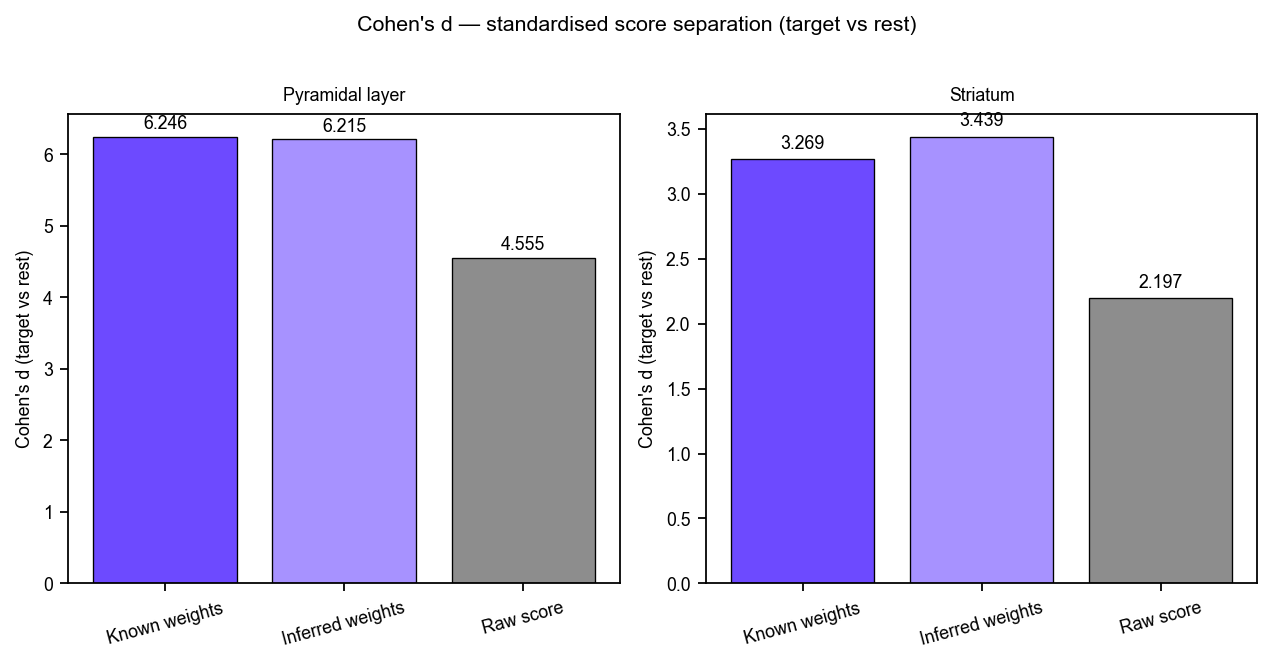

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, ct in zip(axes, [cell_type_1, cell_type_2]):
    sub = cd_df[cd_df["cell_type"] == ct]
    bars = ax.bar(
        sub["label"], sub["cohens_d"],
        color=sub["color"], edgecolor="black", linewidth=0.6,
    )
    ax.set_ylabel("Cohen's d (target vs rest)")
    ax.set_title(ct.replace("_", " "))
    ax.tick_params(axis="x", rotation=15)
    ax.grid(False)
    for bar, val in zip(bars, sub["cohens_d"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Cohen's d — standardised score separation (target vs rest)", y=1.02)
plt.tight_layout()
plt.savefig(f"{figure_dir}19_cohens_d.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

## Known Weights vs Inferred / Raw — Per-spot Correlation

Per-spot correlation of each condition against the known-weights score. A tight relationship for inferred weights but not for raw confirms that CV inference recovers the known-weight structure without access to the actual weights.

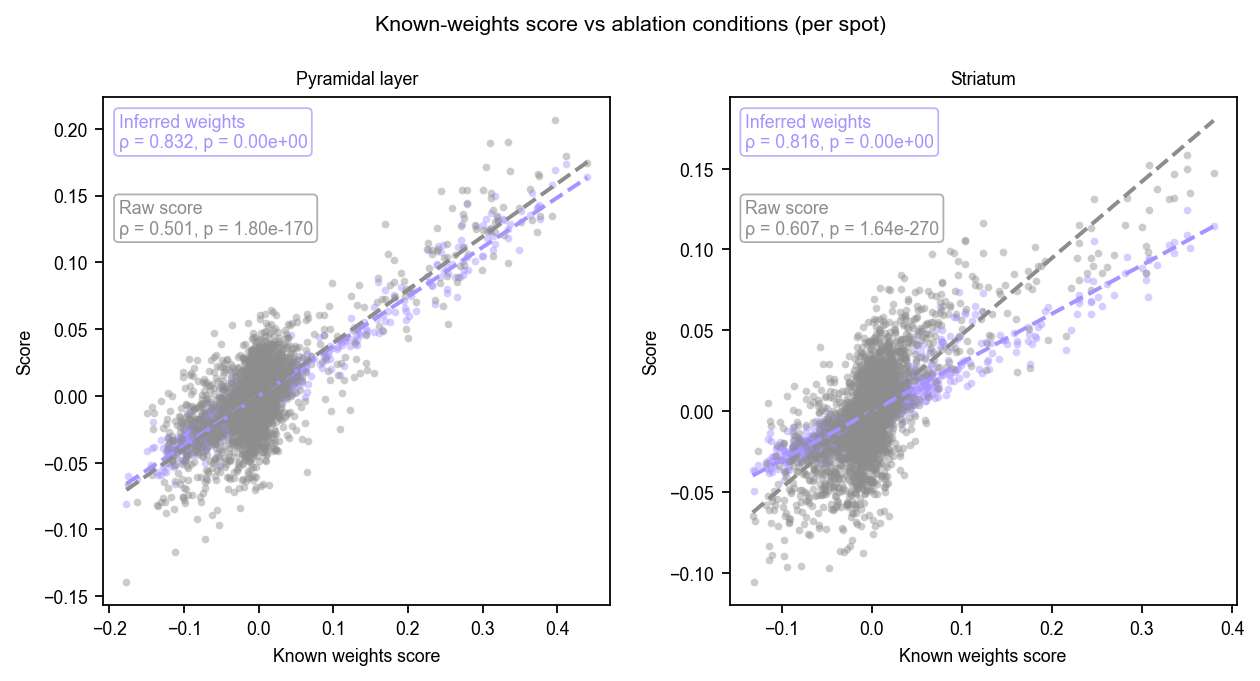

In [18]:
ablation_conditions = [
    ("inferred_score", "Inferred weights", CONDITION_COLORS["inferred"]),
    ("raw_score", "Raw score", CONDITION_COLORS["raw"]),
]

# Make figure width = 2 * height so each of the 2 panels can be square
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # each panel ~4x4

for ax, ct in zip(axes, [cell_type_1, cell_type_2]):
    known_col = f"{ct}_known_score"
    x = adata.obs[known_col].values
    x_range = np.linspace(x.min(), x.max(), 100)

    for cond_suffix, cond_label, color in ablation_conditions:
        y = adata.obs[f"{ct}_{cond_suffix}"].values

        ax.scatter(x, y, c=color, s=12, alpha=0.45, linewidths=0, label=cond_label)

        slope, intercept, *_ = linregress(x, y)
        ax.plot(
            x_range,
            slope * x_range + intercept,
            color=color,
            linewidth=1.8,
            linestyle="--",
        )

        r, p_value = spearmanr(x, y)
        y_pos = 0.97 if cond_suffix.startswith("inferred") else 0.80
        ax.text(
            0.03,
            y_pos,
            f"{cond_label}\nρ = {r:.3f}, p = {p_value:.2e}",
            transform=ax.transAxes,
            va="top",
            fontsize=8,
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.7,
                edgecolor=color,
                linewidth=0.8,
            ),
        )

    # Enforce square axes independent of data limits
    ax.set_box_aspect(1)

    ax.set_xlabel("Known weights score")
    ax.set_ylabel("Score")
    ax.set_title(ct.replace("_", " "))
    ax.grid(False)

plt.suptitle("Known-weights score vs ablation conditions (per spot)", y=1.02)
plt.tight_layout()
plt.savefig(
    f"{figure_dir}19_hexbin_correlations.pdf", bbox_inches="tight"
) if os.path.isdir(figure_dir) else None
plt.show()


## Steiger Z-test

Formal test of whether inferred weights correlate **significantly more strongly** with known weights than raw scores do, accounting for the shared known-weights variable.

In [19]:
def steiger_z(r12, r13, r23, n):
    """Steiger Z: tests whether r12 > r13, variable 1 shared."""
    r_bar = (r12 + r13) / 2
    f = (1 - r23) / (2 * (1 - r_bar**2))
    h = (1 - f * r_bar**2) / (1 - r_bar**2)
    z1, z2 = np.arctanh(r12), np.arctanh(r13)
    Z = (z1 - z2) * np.sqrt((n - 3) / (2 * (1 - r23) * h))
    p = 2 * (1 - stats.norm.cdf(abs(Z)))
    return Z, p


print(f"{'Cell type':<22} {'r(known, inferred)':>22} {'r(known, raw)':>16} "
      f"{'Steiger Z':>12} {'p':>12}")
print("-" * 86)

for ct in [cell_type_1, cell_type_2]:
    obs = adata.obs
    r12 = obs[f"{ct}_known_score"].corr(obs[f"{ct}_inferred_score"])
    r13 = obs[f"{ct}_known_score"].corr(obs[f"{ct}_raw_score"])
    r23 = obs[f"{ct}_inferred_score"].corr(obs[f"{ct}_raw_score"])
    Z, p = steiger_z(r12, r13, r23, n=len(obs))
    print(f"{ct:<22} {r12:>22.4f} {r13:>16.4f} {Z:>12.3f} {p:>12.2e}")

Cell type                  r(known, inferred)    r(known, raw)    Steiger Z            p
--------------------------------------------------------------------------------------
Pyramidal_layer                        0.9628           0.7555       56.726     0.00e+00
Striatum                               0.9172           0.7098       41.614     0.00e+00


## Bootstrapped Spearman Correlations

Bootstrap distributions (n=1,000) of Spearman ρ with the known-weights score. The Mann-Whitney bracket tests whether inferred and raw scores differ significantly in their agreement with known weights.

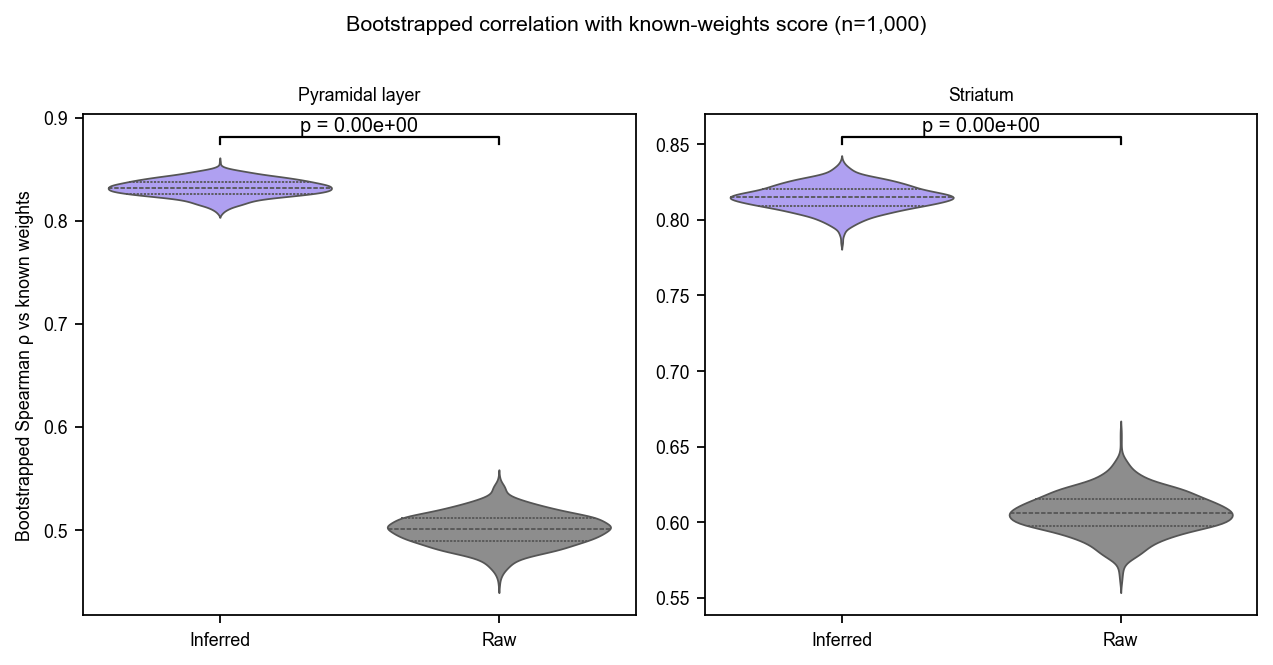

In [20]:
def bootstrap_spearman(x, y, n_boot=1000, seed=0):
    rng_b = np.random.default_rng(seed)
    n = len(x)
    corrs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng_b.integers(0, n, size=n)
        corrs[b] = spearmanr(x[idx], y[idx]).statistic
    return corrs


boot_records = []
for ct in [cell_type_1, cell_type_2]:
    known_col = f"{ct}_known_score"
    for cond_suffix, cond_label in [
        ("inferred_score", "Inferred"),
        ("raw_score",      "Raw"),
    ]:
        boots = bootstrap_spearman(
            adata.obs[known_col].values,
            adata.obs[f"{ct}_{cond_suffix}"].values,
        )
        for val in boots:
            boot_records.append({"cell_type": ct, "condition": cond_label, "rho": val})

boot_df = pd.DataFrame(boot_records)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, ct in zip(axes, [cell_type_1, cell_type_2]):
    sub   = boot_df[boot_df["cell_type"] == ct]
    order = ["Inferred", "Raw"]
    pal   = [CONDITION_COLORS["inferred"], CONDITION_COLORS["raw"]]

    sns.violinplot(
        data=sub, x="condition", y="rho",
        order=order, inner="quart",
        palette=pal, ax=ax, linewidth=0.8,
    )

    g_inf = sub.loc[sub["condition"] == "Inferred", "rho"].values
    g_raw = sub.loc[sub["condition"] == "Raw",      "rho"].values
    _, p  = mannwhitneyu(g_inf, g_raw, alternative="two-sided")

    y_max  = sub["rho"].max()
    y_step = (sub["rho"].max() - sub["rho"].min()) * 0.06
    y_bar  = y_max + y_step
    ax.plot([0, 0, 1, 1],
            [y_bar - y_step * 0.3, y_bar, y_bar, y_bar - y_step * 0.3],
            color="black", linewidth=1)
    ax.text(0.5, y_bar + y_step * 0.2, f"p = {p:.2e}",
            ha="center", fontsize=9)
    ax.set_title(ct.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("Bootstrapped Spearman ρ vs known weights" if ax == axes[0] else "")
    ax.grid(False)

plt.suptitle("Bootstrapped correlation with known-weights score (n=1,000)", y=1.02)
plt.tight_layout()
plt.savefig(f"{figure_dir}19_bootstrap_correlation.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

## CV vs Marker Specificity

CV-based weight inference is valid if high-CV genes are also highly differentially expressed in the target cluster. Signal genes are coloured by their known weight; noise genes (bottom-quartile expression and bottom-quartile CV among all non-signal genes) are shown in grey. The expected pattern is signal genes occupying high CV and positive log2FC, while noise genes cluster near zero on both axes.

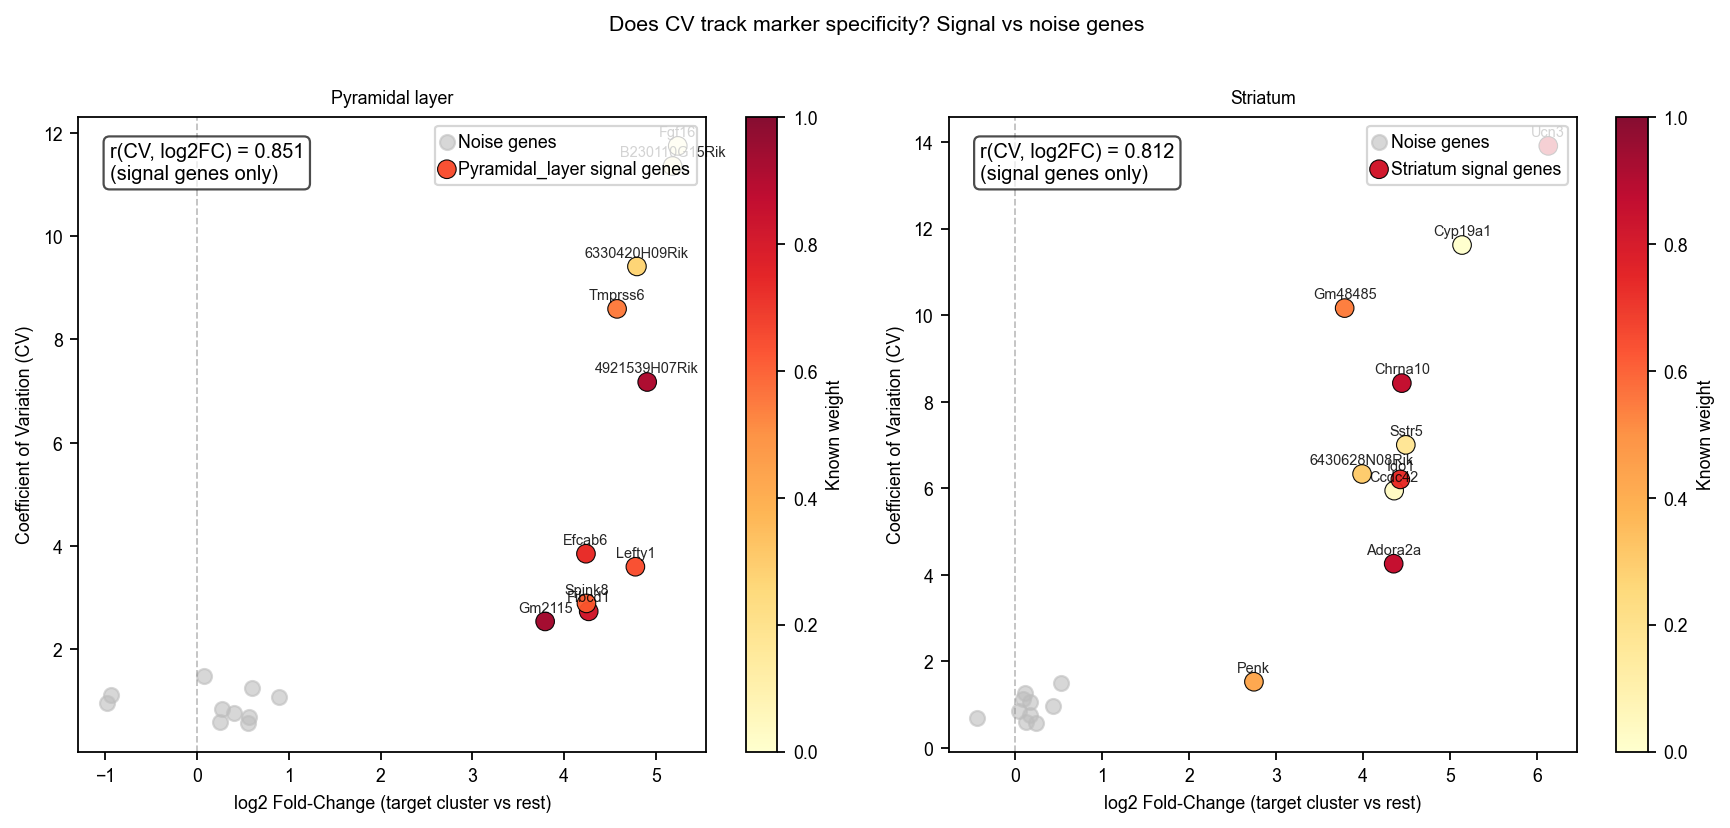

In [21]:
def compute_gene_stats(adata, target_genes, noise_genes, target_cluster, known_weights, cluster_key="cluster"):
    """CV, log2FC (target vs rest), and known weight per gene."""
    mask_target = adata.obs[cluster_key] == target_cluster
    mask_rest   = ~mask_target
    records = []
    for gene_list, is_target in [(target_genes, True), (noise_genes, False)]:
        for gene in gene_list:
            if gene not in adata.var_names:
                continue
            expr = adata[:, gene].X
            expr = expr.toarray().flatten() if issparse(expr) else expr.flatten()
            mu, sigma = expr.mean(), expr.std()
            cv = sigma / mu if mu > 0 else 0.0
            log2fc = np.log2(
                (expr[mask_target].mean() + 1e-6) / (expr[mask_rest].mean() + 1e-6)
            )
            records.append({
                "gene":         gene,
                "CV":           cv,
                "log2FC":       log2fc,
                "known_weight": known_weights.get(gene, np.nan),
                "is_target":    is_target,
            })
    return pd.DataFrame(records)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (ct, sig_target) in zip(axes, [
    (cell_type_1, list(signature_1)),
    (cell_type_2, list(signature_2)),
]):
    kw_dict = known_weights_dict[f"{ct}_known"]
    gdf = compute_gene_stats(adata, sig_target, noise_genes, ct, kw_dict)

    ax.scatter(
        gdf.loc[~gdf["is_target"], "log2FC"],
        gdf.loc[~gdf["is_target"], "CV"],
        c="#BDBDBD", s=45, alpha=0.6, label="Noise genes", zorder=2,
    )
    sc = ax.scatter(
        gdf.loc[gdf["is_target"], "log2FC"],
        gdf.loc[gdf["is_target"], "CV"],
        c=gdf.loc[gdf["is_target"], "known_weight"],
        cmap="YlOrRd", vmin=0, vmax=1,
        s=70, alpha=0.95, edgecolors="black", linewidth=0.5,
        label=f"{ct} signal genes", zorder=3,
    )
    plt.colorbar(sc, ax=ax, label="Known weight")

    for _, r in gdf[gdf["is_target"]].iterrows():
        ax.annotate(r["gene"], (r["log2FC"], r["CV"]),
                    fontsize=6.5, alpha=0.85, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points")

    tg      = gdf[gdf["is_target"]]
    r_cv_fc = tg["CV"].corr(tg["log2FC"])
    ax.text(0.05, 0.96,
            f"r(CV, log2FC) = {r_cv_fc:.3f}\n(signal genes only)",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("log2 Fold-Change (target cluster vs rest)")
    ax.set_ylabel("Coefficient of Variation (CV)")
    ax.set_title(ct.replace("_", " "))
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(False)

plt.suptitle("Does CV track marker specificity? Signal vs noise genes", y=1.02)
plt.tight_layout()
plt.savefig(f"{figure_dir}19_cv_vs_log2fc.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

## Summary

| Comparison | Question |
|---|---|
| A vs C | Does silencing irrelevant genes (known weights) beat equal weighting (raw)? |
| B vs C | Does CV inference recover a signal that equal weighting cannot? |
| A vs B | How close is data-driven CV inference to provided weights? |

In [22]:
final = cd_df[["cell_type", "label", "cohens_d"]].copy()
final = final.sort_values(["cell_type", "cohens_d"], ascending=[True, False])
final.columns = ["Cell type", "Condition", "Cohen's d"]
print(final.to_string(index=False))

      Cell type        Condition  Cohen's d
Pyramidal_layer    Known weights   6.245838
Pyramidal_layer Inferred weights   6.215001
Pyramidal_layer        Raw score   4.554517
       Striatum Inferred weights   3.439257
       Striatum    Known weights   3.268769
       Striatum        Raw score   2.196848


## Comparison with other methods

In [23]:
from score_signatures import score_signatures

In [24]:
# Same gene sets as conditions B and C
benchmark_sigs = {
    cell_type_1: list(signature_1) + noise_genes,
    cell_type_2: list(signature_2) + noise_genes,
}

adata = score_signatures(
    adata,
    signatures_dict=benchmark_sigs,
    methods=["aucell", "scanpy", "ssgsea", "gsva", "zscore"],
)

bench_cols = [c for c in adata.obs.columns if any(c.endswith(f"_{m}") for m in ["aucell", "scanpy", "ssgsea", "gsva", "zscore"])]
print(f"{len(bench_cols)} benchmark score columns added:")
for c in sorted(bench_cols):
    print(f"  {c}")

10 benchmark score columns added:
  Pyramidal_layer_aucell
  Pyramidal_layer_gsva
  Pyramidal_layer_scanpy
  Pyramidal_layer_ssgsea
  Pyramidal_layer_zscore
  Striatum_aucell
  Striatum_gsva
  Striatum_scanpy
  Striatum_ssgsea
  Striatum_zscore


In [25]:
BENCH_METHODS = [
    {"key": "aucell", "label": "AUCell", "color": "#73C163"},
    {"key": "gsva", "label": "GSVA", "color": "#D65F5F"},
    {"key": "ssgsea", "label": "ssGSEA", "color": "#956CB4"},
    {"key": "zscore", "label": "Z-score", "color": "#8C613C"},
    {"key": "scanpy", "label": "Scanpy", "color": "#DC7EC0"}
]

bench_cd_records = []
for ct in [cell_type_1, cell_type_2]:
    mask_target = (adata.obs["cluster"] == ct).values
    for m in BENCH_METHODS:
        col = f"{ct}_{m['key']}"
        if col not in adata.obs.columns:
            print(f"WARNING: {col} not found, skipping")
            continue
        scores = adata.obs[col].values
        d = cohens_d(scores[mask_target], scores[~mask_target])
        bench_cd_records.append({
            "cell_type": ct, "key": m["key"], "label": m["label"],
            "col": col, "color": m["color"], "cohens_d": d,
        })

bench_cd_df = pd.DataFrame(bench_cd_records)

# Merge with EnrichMap conditions
all_cd_df = pd.concat(
    [cd_df[["cell_type", "key", "label", "col", "color", "cohens_d"]], bench_cd_df],
    ignore_index=True,
)

print(all_cd_df[["cell_type", "label", "cohens_d"]].to_string(index=False))

      cell_type            label  cohens_d
Pyramidal_layer    Known weights  6.245838
Pyramidal_layer Inferred weights  6.215001
Pyramidal_layer        Raw score  4.554517
       Striatum    Known weights  3.268769
       Striatum Inferred weights  3.439257
       Striatum        Raw score  2.196848
Pyramidal_layer           AUCell  3.870216
Pyramidal_layer             GSVA  2.343783
Pyramidal_layer           ssGSEA  4.016011
Pyramidal_layer          Z-score  5.308851
Pyramidal_layer           Scanpy  5.093490
       Striatum           AUCell  2.504729
       Striatum             GSVA  1.344225
       Striatum           ssGSEA  1.804358
       Striatum          Z-score  2.285149
       Striatum           Scanpy  2.387021


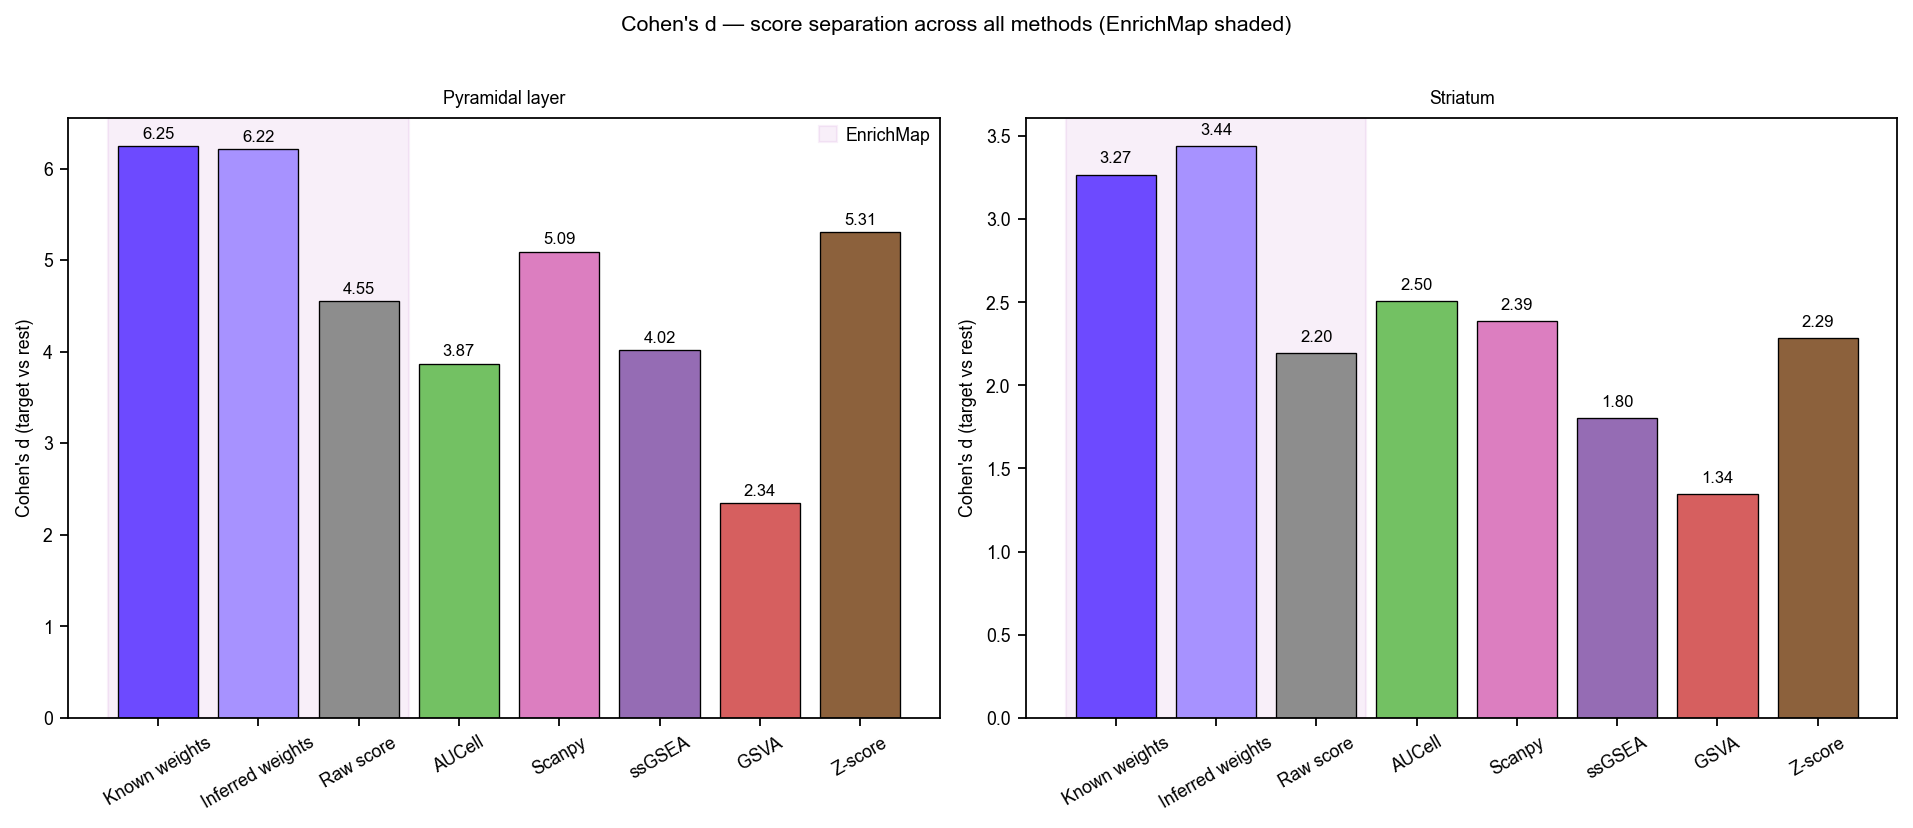

In [26]:
# ----- Plot -----
METHOD_ORDER = [
    "known",
    "inferred",
    "raw",
    "aucell",
    "scanpy",
    "ssgsea",
    "gsva",
    "zscore",
]
order_map = {k: i for i, k in enumerate(METHOD_ORDER)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ct in zip(axes, [cell_type_1, cell_type_2]):
    sub = all_cd_df[all_cd_df["cell_type"] == ct].copy()
    sub["_order"] = sub["key"].map(order_map)
    sub = sub.sort_values("_order")

    bars = ax.bar(
        sub["label"],
        sub["cohens_d"],
        color=sub["color"],
        edgecolor="black",
        linewidth=0.6,
    )

    # Shade the three EnrichMap conditions
    ax.axvspan(-0.5, 2.5, alpha=0.07, color="#9C27B0", zorder=0, label="EnrichMap")

    ax.set_ylabel("Cohen's d (target vs rest)")
    ax.set_title(ct.replace("_", " "))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)
    for bar, val in zip(bars, sub["cohens_d"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
        )

axes[0].legend(fontsize=8, loc="upper right")
plt.suptitle(
    "Cohen's d — score separation across all methods (EnrichMap shaded)", y=1.02
)
plt.tight_layout()
plt.savefig(
    f"{figure_dir}19_cohens_d_comparison.pdf", bbox_inches="tight"
) if os.path.isdir(figure_dir) else None
plt.show()

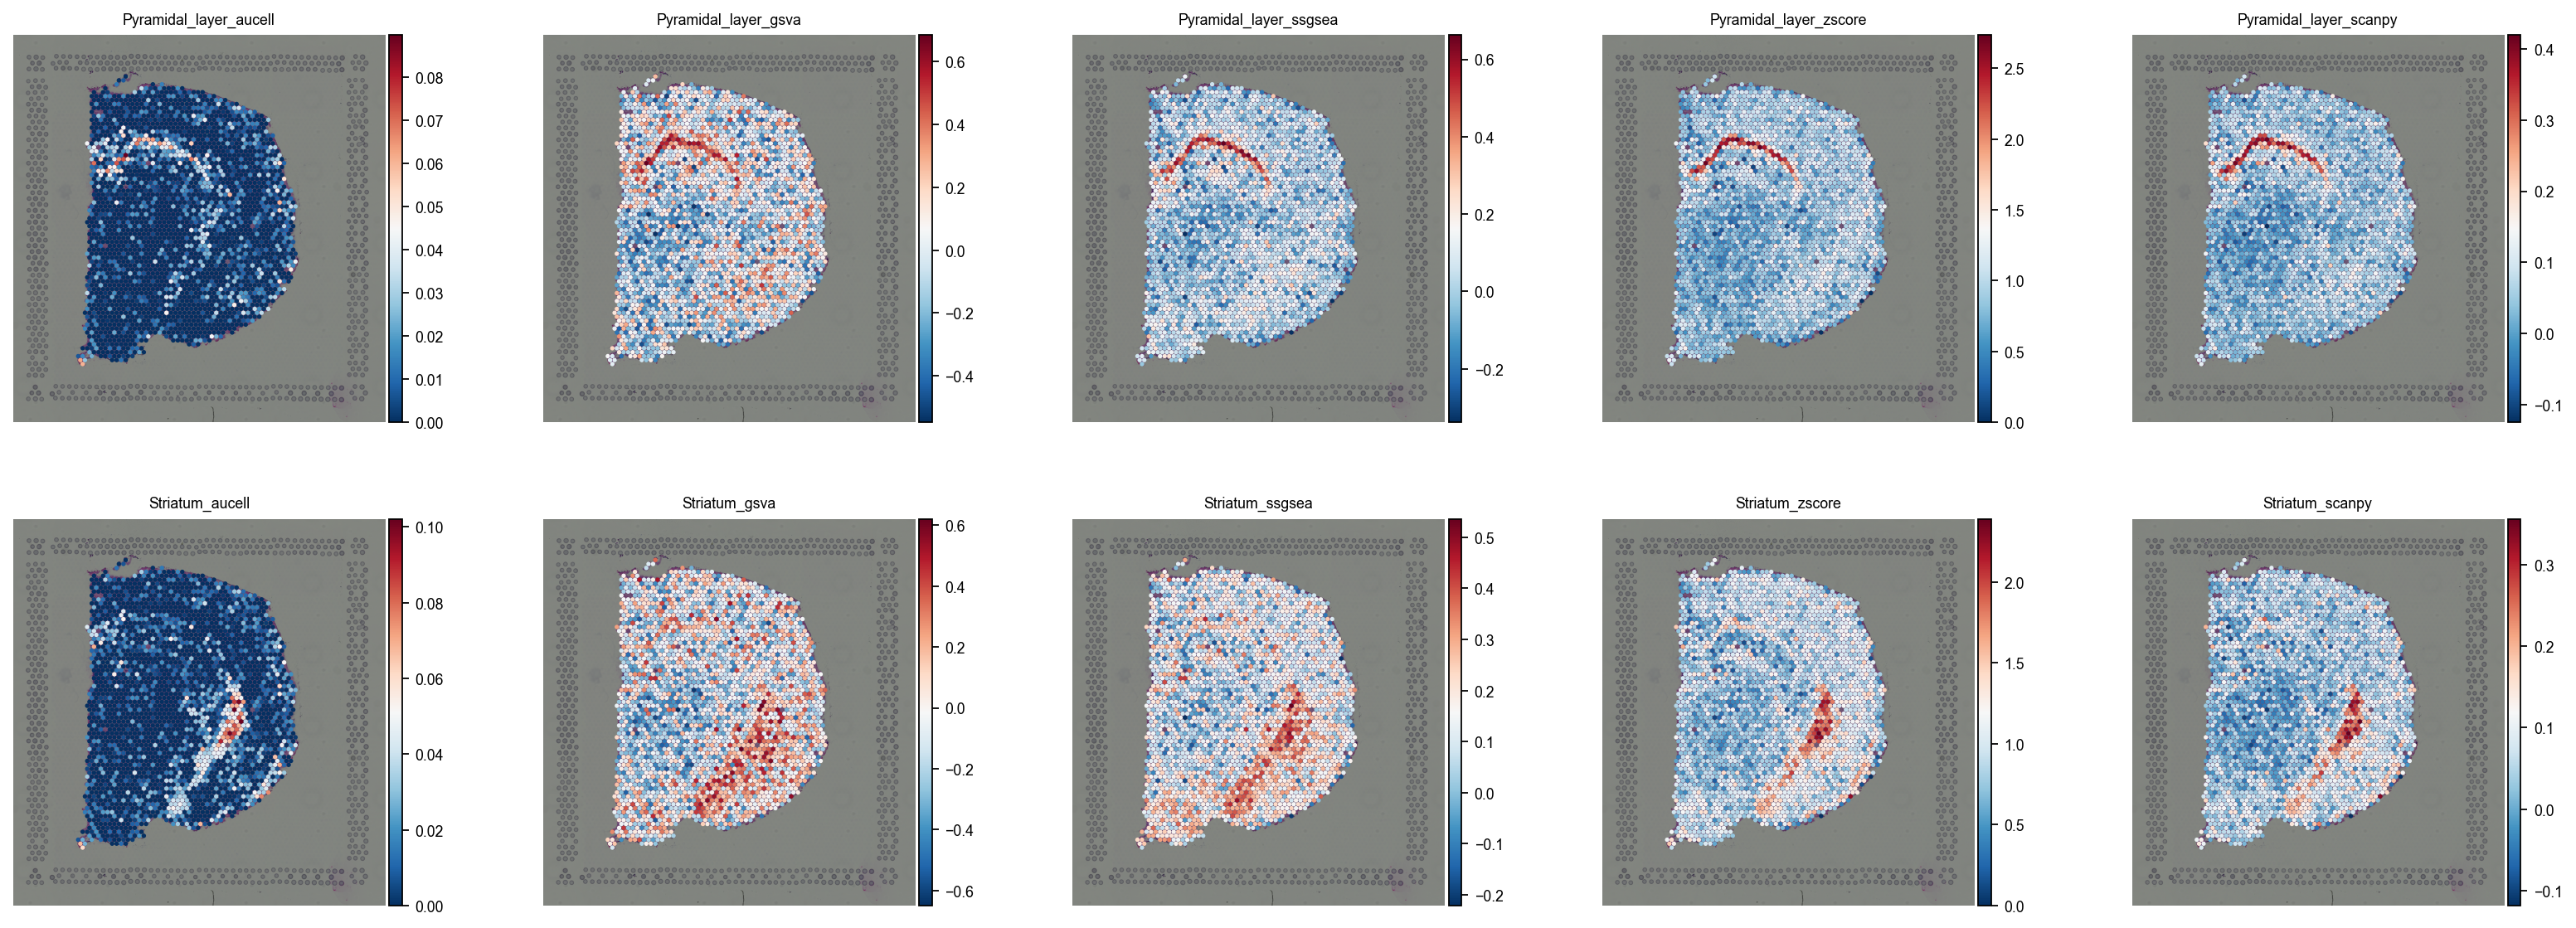

In [27]:
# plot all methods together in a single figure
sq.pl.spatial_scatter(
    adata,
    color=[f"{ct}_{m['key']}" for ct in [cell_type_1, cell_type_2] for m in BENCH_METHODS],
    size=spot_size,
    ncols=5,
    cmap="RdBu_r",
    save="19visium_weights_spatial_benchmarks.pdf",
)